In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
from matplotlib.colors import to_rgb, to_hex
from pathlib import Path
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.patches as mpatches
from datetime import datetime
import geopandas as gpd
from pyproj import CRS

In [2]:
def plot_optimal_cluster(ax):
    colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488', '#F39B7F', '#8491B4', '#91D1C2', '#dC0000', '#7E6148', '#B09C85']
    df=pd.read_excel(r'output/scenario=all/cell=40km/threshold=5/cluster_number/all_40km_5_height_vs_K.xlsx')
    ax.plot(df['n_clusters'], df['normalized_node_height'], color='black', linewidth=2, zorder=0)
    ax.scatter(df['n_clusters'][12], df['normalized_node_height'][12], marker='o', edgecolor='#E64B35', facecolor='none', s=20, zorder=1)
    ax.set_xlim(-5, 205)
    ax.set_ylim(-2, 32)
    optimal_K=13
    ax.axvline(optimal_K, color='gray', linestyle='--', linewidth=1, label=f'Optimal cluster number = {optimal_K}')
    ax.text(optimal_K + 3, 30, f'Optimal cluster number = {optimal_K:d}',fontsize=10,ha='left',va='top', fontfamily='Arial')
    ax.set_xlabel('Cluster number', fontsize=10, fontfamily='Arial')
    ax.set_ylabel('Cophenetic distance', fontsize=10, fontfamily='Arial')
    ax.tick_params(axis='both', which='major', labelsize=10)

In [3]:
def plot_silhouette(ax):
    import numpy as np
    import pandas as pd

    df = pd.read_excel(
        r'output/scenario=all/cell=40km/threshold=5/cluster_number/all_40km_5_silhouette.xlsx'
    )

    cluster_colors = {
        1:  {'color': '#E64B35', 'alpha': 1.0},
        2:  {'color': '#E64B35', 'alpha': 0.75},
        3:  {'color': '#E64B35', 'alpha': 0.5},
        4:  {'color': '#E64B35', 'alpha': 0.25},
        5:  {'color': '#00A087', 'alpha': 1.0},
        6:  {'color': '#00A087', 'alpha': 0.75},
        7:  {'color': '#00A087', 'alpha': 0.5},
        8:  {'color': '#00A087', 'alpha': 0.25},
        9:  {'color': '#3C5488', 'alpha': 1.0},
        10: {'color': '#3C5488', 'alpha': 0.75},
        11: {'color': '#7E6148', 'alpha': 1.0},
        12: {'color': '#7E6148', 'alpha': 0.75},
        13: {'color': '#7E6148', 'alpha': 0.5}
    }

    x_lower = 0
    gap = 10

    cluster_labels = df['cluster'].values
    sil_values = df['silhouette_value'].values
    sil_avg = sil_values.mean()

    unique_clusters = np.sort(df['cluster'].unique())

    # 需要画竖线的 cluster（在其后）
    split_clusters = {4, 8, 10}

    # ------------------------------------------------
    # Horizontal silhouette plot
    # ------------------------------------------------
    for cid in unique_clusters:
        vals = sil_values[cluster_labels == cid]
        vals.sort()

        size = len(vals)
        x_upper = x_lower + size

        ax.fill_between(
            np.arange(x_lower, x_upper),
            0,
            vals,
            facecolor=cluster_colors[cid]['color'],
            alpha=cluster_colors[cid]['alpha'],
            edgecolor='none'
        )

        # ---------- 关键：在指定 cluster 后画竖线 ----------
        if cid in split_clusters:
            ax.axvline(
                x_upper + gap / 2,
                color='gray',
                linestyle='--',
                linewidth=1,
                zorder=1
            )

        x_lower = x_upper + gap

    # ------------------------------------------------
    # Average silhouette (horizontal reference line)
    # ------------------------------------------------
    # ax.axhline(
    #     sil_avg,
    #     linestyle='--',
    #     color='black',
    #     linewidth=1,
    #     zorder=10
    # )

    ax.text(
        1200,
        0.9,
        f'Mean = {sil_avg:.2f}',
        ha='right',
        va='center',
        fontsize=10,
        fontfamily='Arial'
    )

    # ------------------------------------------------
    # Axis formatting
    # ------------------------------------------------
    # ax.set_xticks([])
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlim(-100, 4800)
    ax.set_xlabel('Grid cell', fontsize=10, fontfamily='Arial')
    ax.set_ylabel('Silhouette width', fontsize=10, fontfamily='Arial')
    ax.tick_params(axis='y', which='major', labelsize=10)
    ax.tick_params(axis='x', which='major', labelsize=10, color='white')
    xticks = [0, 1000, 2000, 3000, 4000]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, color='white', fontsize=10)

In [4]:
def adjust_alpha(color_hex, alpha):
    """将十六进制颜色和透明度合并为新的十六进制颜色"""
    rgb = to_rgb(color_hex)
    # 模拟透明度效果：混合白色背景
    blended = [1 - alpha + c * alpha for c in rgb]
    return to_hex(blended)

def plot_dendrogram(ax):
    # 1. 读取数据
    base = Path(f'output/scenario=all/cell=40km/threshold=5')
    cluster_df = pd.read_excel(base / 'cluster_number' / f'all_40km_5_grid_cluster.xlsx')
    cluster_dict = dict(zip(cluster_df['grid_index'], cluster_df['cluster']))
    n_clusters = cluster_df['cluster'].nunique()
    clusters = sorted(cluster_df['cluster'].unique())
    
    dissim_matrix = pd.read_excel(base / f'all_40km_5_beta_diversity_matrix.xlsx',index_col=0)
    condensed_dist = squareform(dissim_matrix.values)
    Z = linkage(condensed_dist, method='ward')
    threshold_distance = Z[-(n_clusters - 1), 2]


    # 2. 颜色定义（包含原始颜色和透明度信息）
    cluster_styles = {
        1:  {'color': '#E64B35', 'alpha': 1.0},
        2:  {'color': '#E64B35', 'alpha': 0.75},
        3:  {'color': '#E64B35', 'alpha': 0.5},
        4:  {'color': '#E64B35', 'alpha': 0.25},
        5:  {'color': '#00A087', 'alpha': 1.0},
        6:  {'color': '#00A087', 'alpha': 0.75},
        7:  {'color': '#00A087', 'alpha': 0.5},
        8:  {'color': '#00A087', 'alpha': 0.25},
        9:  {'color': '#3C5488', 'alpha': 1.0},
        10: {'color': '#3C5488', 'alpha': 0.75},
        11: {'color': '#7E6148', 'alpha': 1.0},
        12: {'color': '#7E6148', 'alpha': 0.75},
        13: {'color': '#7E6148', 'alpha': 0.5}
    }

    # 3. 预计算带透明度的显示颜色（关键修正：使用正确的函数名）
    cluster_colors = {cl: adjust_alpha(style['color'], style['alpha']) 
                    for cl, style in cluster_styles.items()}

    # 4. link_color_func 使用预处理后的颜色
    def link_color_func(k):
        if k < len(dissim_matrix):
            return '#000000'
        
        def get_leaf_clusters(node):
            if node < len(dissim_matrix):
                grid_id = dissim_matrix.index[node]
                return {cluster_dict[grid_id]}
            left = int(Z[node - len(dissim_matrix), 0])
            right = int(Z[node - len(dissim_matrix), 1])
            return get_leaf_clusters(left) | get_leaf_clusters(right)
        
        clusters = get_leaf_clusters(k)
        return cluster_colors[list(clusters)[0]] if len(clusters) == 1 else '#000000'

    # 5. 绘制树状图
    dendrogram(
        Z,
        ax=ax,
        no_labels=True,
        color_threshold=threshold_distance,
        above_threshold_color='black',
        link_color_func=link_color_func
    )

    # 7. 样式调整
    ax.axhline(y=12, linestyle='--', color='black', lw=1)
    ax.set_ylabel('Cophenetic distance', fontsize=10, fontfamily='Arial')
    ax.set_ylim(0, 30)
    for side in ['top', 'right', 'bottom']:
        ax.spines[side].set_visible(False)
    ax.spines['left'].set_position(('outward', 10))
    ax.tick_params(axis='both', which='major', labelsize=10)

In [5]:
def plot_map(ax, xlim_left,  xlim_right, ylim_bottom, ylim_top):
    # ======================================================
    # 1. 构造文件路径
    # ======================================================
    cluster_file = Path(
        f'output/scenario=all/cell=40km/threshold=5/cluster_number/all_40km_5_silhouette.xlsx'
    )
    grid_shp_file = Path(
        f'output/scenario=all/cell=40km/all_40km_grid_map.geojson'
    )

    # ======================================================
    # 2. 读取数据
    # ======================================================
    cluster_df = pd.read_excel(cluster_file)
    grid_gdf = gpd.read_file(grid_shp_file)

    # 合并聚类信息
    grid_gdf = grid_gdf.merge(cluster_df, on='grid_index', how='left')
    laea_crs = CRS.from_proj4("+proj=laea +lat_0=40 +lon_0=104 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs")
    grid_gdf=grid_gdf.to_crs(laea_crs)

    # ======================================================
    # 3. 设置 cluster 颜色
    # ======================================================
    cluster_colors = {
        1:  {'color': '#E64B35', 'alpha': 1.0},
        2:  {'color': '#E64B35', 'alpha': 0.75},
        3:  {'color': '#E64B35', 'alpha': 0.5},
        4:  {'color': '#E64B35', 'alpha': 0.25},
        5:  {'color': '#00A087', 'alpha': 1.0},
        6:  {'color': '#00A087', 'alpha': 0.75},
        7:  {'color': '#00A087', 'alpha': 0.5},
        8:  {'color': '#00A087', 'alpha': 0.25},
        9:  {'color': '#3C5488', 'alpha': 1.0},
        10: {'color': '#3C5488', 'alpha': 0.75},
        11: {'color': '#7E6148', 'alpha': 1.0},
        12: {'color': '#7E6148', 'alpha': 0.75},
        13: {'color': '#7E6148', 'alpha': 0.5}
    }

    grid_gdf['cluster'] = grid_gdf['cluster'].fillna(-1)
    clusters = sorted(grid_gdf.loc[grid_gdf['cluster'] != -1, 'cluster'].unique())

    # ======================================================
    # 4. 创建图和子图
    # ======================================================
    
    # ======================================================
    # 5. 绘制中国边界
    # ======================================================
    china = gpd.read_file('../0_map/中国_省_202509_GS(2024)0650.geojson')
    # china = china[china['name'] != '境界线'].reset_index(drop=True)
    china=china.to_crs(laea_crs)
    # china_dissolved = china.dissolve()
    china.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, zorder=2)

    # ======================================================
    # 6. 绘制 No cluster 的格子（灰色 + hatch）
    # ======================================================
    no_cluster_gdf = grid_gdf[grid_gdf['cluster'] == -1]

    for geom in no_cluster_gdf.geometry:
        if geom.geom_type == 'Polygon':
            polygons = [geom]
        elif geom.geom_type == 'MultiPolygon':
            polygons = geom.geoms
        else:
            continue

        for poly in polygons:
            ax.add_patch(
                mpatches.Polygon(
                    np.array(poly.exterior.coords),
                    facecolor='white',
                    linewidth=0.1
                )
            )

    # ======================================================
    # 7. 绘制有 cluster 的格子，且silhouette值为正
    # ======================================================
    clustered_gdf = grid_gdf[(grid_gdf['cluster'] != -1) & (grid_gdf['silhouette_value']>0)].copy()
    clustered_gdf['color'] = clustered_gdf['cluster'].map(lambda x: cluster_colors[x]['color'])
    clustered_gdf['alpha'] = clustered_gdf['cluster'].map(lambda x: cluster_colors[x]['alpha'])

    clustered_gdf.plot(
        color=clustered_gdf['color'],
        alpha=clustered_gdf['alpha'],
        linewidth=0.1,
        edgecolor='None',
        ax=ax
    )

    # ======================================================
    # 7.1 绘制有 cluster 的格子，且silhouette值为负
    # ======================================================
    clustered_gdf = grid_gdf[(grid_gdf['cluster'] != -1) & (grid_gdf['silhouette_value']<0)].copy()
    # clustered_gdf['color'] = clustered_gdf['cluster'].map(cluster_colors)

    clustered_gdf.plot(
        facecolor='lightgrey',
        edgecolor='black',
        hatch='///',
        linewidth=0.1,
        ax=ax
    )

    # ======================================================
    # 9. 地图样式设置
    # ======================================================
    if ylim_top==2*1e6:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(xlim_left, xlim_right)
    ax.set_ylim(ylim_bottom, ylim_top)
    ax.set_aspect('equal')

In [6]:
def plot_legend(ax):
    import matplotlib.patches as mpatches

    cluster_colors = {
        1:  {'color': '#E64B35', 'alpha': 1.0},
        2:  {'color': '#E64B35', 'alpha': 0.75},
        3:  {'color': '#E64B35', 'alpha': 0.5},
        4:  {'color': '#E64B35', 'alpha': 0.25},
        5:  {'color': '#00A087', 'alpha': 1.0},
        6:  {'color': '#00A087', 'alpha': 0.75},
        7:  {'color': '#00A087', 'alpha': 0.5},
        8:  {'color': '#00A087', 'alpha': 0.25},
        9:  {'color': '#3C5488', 'alpha': 1.0},
        10: {'color': '#3C5488', 'alpha': 0.75},
        11: {'color': '#7E6148', 'alpha': 1.0},
        12: {'color': '#7E6148', 'alpha': 0.75},
        13: {'color': '#7E6148', 'alpha': 0.5}
    }

    cluster_to_region = {
        1: 'South China', 
        2: 'South China',
        3: 'South China', 
        4: 'South China', 
        5: 'North-Northeast',
        6: 'North-Northeast',
        7: 'North-Northeast',
        8: 'North-Northeast', 
        9: 'Qinghai-Tibet Plateau',
        10: 'Qinghai-Tibet Plateau',
        11: 'Northwestern',
        12: 'Northwestern',
        13: 'Northwestern',
    }

    # 生成 Patch 对象
    handles = [
        mpatches.Patch(
            facecolor=cluster_colors[cl]['color'],
            alpha=cluster_colors[cl]['alpha'],
            label=f'Cluster {cl} ({cluster_to_region[cl]})'
        )
        for cl in range(1, 14)   # ✅ 注意从1到13
    ]

    # 添加 No cluster
    handles.append(
        mpatches.Patch(facecolor='white', label='No cluster', edgecolor='black')
    )

    handles.append(
        mpatches.Patch(facecolor='lightgrey', label='Negative silhouette width', edgecolor='black', hatch='///')
    )

    ax.legend(handles=handles, loc='center', frameon=False, ncols=1, title='Cluster', title_fontsize=10, prop={'family': 'Arial'})
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_axis_off()

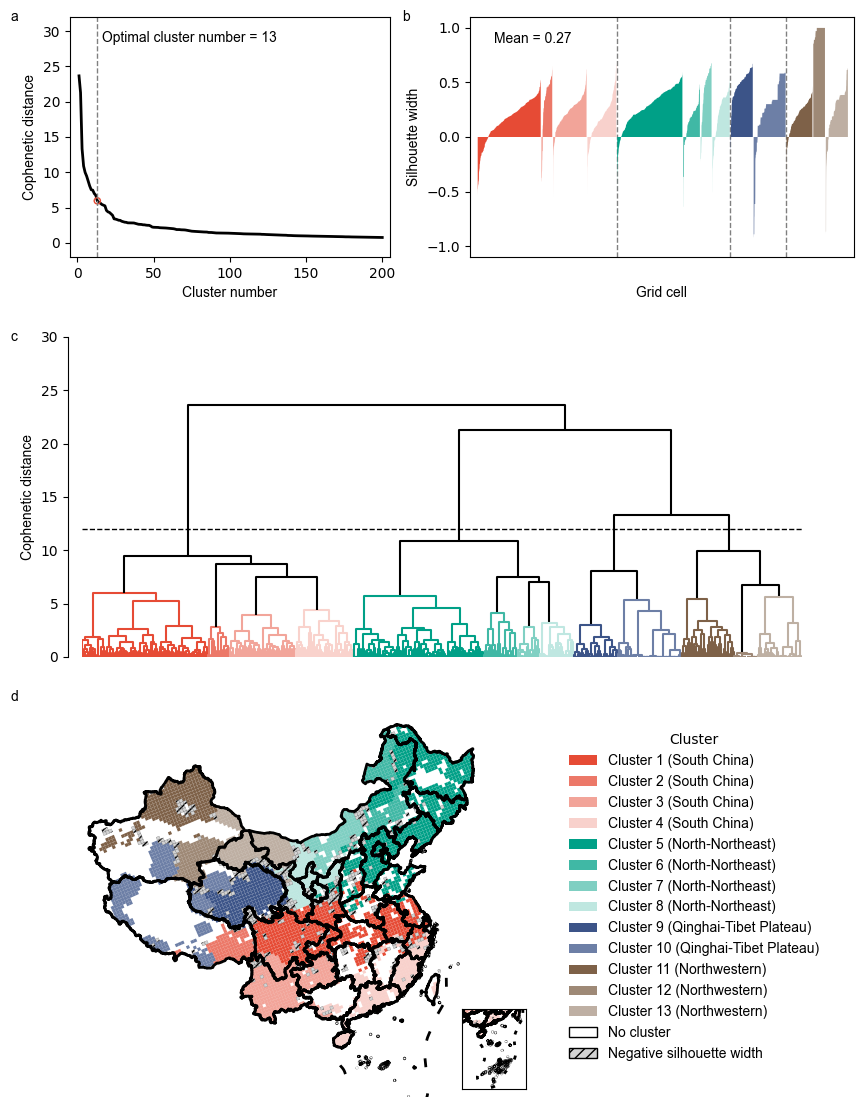

In [7]:
fig = plt.figure(figsize=(8, 8))

letters = list(string.ascii_lowercase)

# ============================================================
#                       Optimal cluster number
# ============================================================
ax1 = fig.add_axes([0.02, 0.7, 0.4, 0.3])
plot_optimal_cluster(ax1)
fig.text(-0.05, 1.0, letters[0], ha='center', va='center', fontsize=10, fontfamily='Arial')
# ============================================================
#                      Silhouette analysis
# ============================================================
ax2 = fig.add_axes([0.52, 0.7, 0.48, 0.3])
plot_silhouette(ax2)
fig.text(0.44, 1.0, letters[1], ha='center', va='center', fontsize=10, fontfamily='Arial')

# ============================================================
#                      Dendrogram
# ============================================================
ax3 = fig.add_axes([0.035, 0.2, 0.9, 0.4])
plot_dendrogram(ax3)
fig.text(-0.05, 0.6, letters[2], ha='center', va='center', fontsize=10, fontfamily='Arial')

# # ============================================================
# #                      Map
# # ============================================================
ax4 = fig.add_axes([0.0, -0.35, 0.6, 0.5])
plot_map(ax4, -3*1e6, 3*1e6, -3*1e6, 2*1e6)
fig.text(-0.05, 0.15, letters[3], ha='center', va='center', fontsize=10, fontfamily='Arial')

ax5 = fig.add_axes([0.51, -0.35+0.01, 0.08, 0.08*1.25])
plot_map(ax5, 0*1e6, 2*1e6, -4*1e6, -1.5*1e6)

# # ============================================================
# #                      Legend
# # ============================================================
ax6 = fig.add_axes([0.6, -0.35, 0.4, 0.5])
plot_legend(ax6)

date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
# plt.savefig(f'figure/Extended Data Figure1_{date_str}.pdf', bbox_inches='tight', pad_inches=0.05)
plt.savefig(f'figure/Extended Data Figure1_{date_str}.tif', bbox_inches='tight', pad_inches=0.05, dpi=500)
plt.show()

In [8]:
def plot_map(ax, xlim, ylim, xcor, ycor):
    # ======================================================
    # 1. 构造文件路径
    # ======================================================
    cluster_file = Path(
        f'output/scenario=all/cell=40km/threshold=5/cluster_number/all_40km_5_silhouette.xlsx'
    )
    grid_shp_file = Path(
        f'output/scenario=all/cell=40km/all_40km_grid_map.geojson'
    )

    # ======================================================
    # 2. 读取数据
    # ======================================================
    cluster_df = pd.read_excel(cluster_file)
    grid_gdf = gpd.read_file(grid_shp_file)

    # 合并聚类信息
    grid_gdf = grid_gdf.merge(cluster_df, on='grid_index', how='left')

    # ======================================================
    # 3. 设置 cluster 颜色
    # ======================================================
    cluster_colors = {
        1:  {'color': '#E64B35', 'alpha': 1.0},
        2:  {'color': '#E64B35', 'alpha': 0.75},
        3:  {'color': '#E64B35', 'alpha': 0.5},
        4:  {'color': '#E64B35', 'alpha': 0.25},
        5:  {'color': '#00A087', 'alpha': 1.0},
        6:  {'color': '#00A087', 'alpha': 0.75},
        7:  {'color': '#00A087', 'alpha': 0.5},
        8:  {'color': '#00A087', 'alpha': 0.25},
        9:  {'color': '#3C5488', 'alpha': 1.0},
        10: {'color': '#3C5488', 'alpha': 0.75},
        11: {'color': '#7E6148', 'alpha': 1.0},
        12: {'color': '#7E6148', 'alpha': 0.75},
        13: {'color': '#7E6148', 'alpha': 0.5}
    }

    grid_gdf['cluster'] = grid_gdf['cluster'].fillna(-1)
    clusters = sorted(grid_gdf.loc[grid_gdf['cluster'] != -1, 'cluster'].unique())

    # ======================================================
    # 4. 创建图和子图
    # ======================================================
    
    # ======================================================
    # 5. 绘制中国边界
    # ======================================================
    china = gpd.read_file('../0_map/中国_省_202509_GS(2024)0650.geojson')
    china = china[china['name'] != '境界线'].reset_index(drop=True)
    china_dissolved = china.dissolve()
    china_dissolved.boundary.plot(ax=ax, color='black', linewidth=2)

    region=gpd.read_file('output/regions_boundary_20260115.geojson')
    region.boundary.plot(ax=ax, color='red', linewidth=2)

    ax.scatter(xcor, ycor, s=100, marker='*', color='black', zorder=10)
    # ======================================================
    # 6. 绘制 No cluster 的格子（灰色 + hatch）
    # ======================================================
    no_cluster_gdf = grid_gdf[grid_gdf['cluster'] == -1]

    for geom in no_cluster_gdf.geometry:
        if geom.geom_type == 'Polygon':
            polygons = [geom]
        elif geom.geom_type == 'MultiPolygon':
            polygons = geom.geoms
        else:
            continue

        for poly in polygons:
            ax.add_patch(
                mpatches.Polygon(
                    np.array(poly.exterior.coords),
                    facecolor='white',
                    linewidth=0.1
                )
            )

    # ======================================================
    # 7. 绘制有 cluster 的格子，且silhouette值为正
    # ======================================================
    clustered_gdf = grid_gdf[(grid_gdf['cluster'] != -1) & (grid_gdf['silhouette_value']>0)].copy()
    clustered_gdf['color'] = clustered_gdf['cluster'].map(lambda x: cluster_colors[x]['color'])
    clustered_gdf['alpha'] = clustered_gdf['cluster'].map(lambda x: cluster_colors[x]['alpha'])

    clustered_gdf.plot(
        color=clustered_gdf['color'],
        alpha=clustered_gdf['alpha'],
        linewidth=0.1,
        edgecolor='None',
        ax=ax
    )

    # ======================================================
    # 7.1 绘制有 cluster 的格子，且silhouette值为负
    # ======================================================
    clustered_gdf = grid_gdf[(grid_gdf['cluster'] != -1) & (grid_gdf['silhouette_value']<0)].copy()
    # clustered_gdf['color'] = clustered_gdf['cluster'].map(cluster_colors)

    clustered_gdf.plot(
        facecolor='lightgrey',
        edgecolor='black',
        hatch='///',
        linewidth=0.1,
        ax=ax
    )

    province_labels = {
        'Xinjiang': (84, 41), 'Xizang': (88, 30), 'Qinghai': (93, 35), 'Gansu': (100, 38),
        'Sichuan': (100, 30), 'Yunnan': (99, 24), 'Guangxi': (106, 22.5), 'Hainan': (107, 19),
        'Guizhou': (104.5, 26.5), 'Guangdong': (110, 23.5), 'Chongqing': (103, 29),
        'Hunan': (109.5, 27), 'Hubei': (111, 30.5), 'Jiangxi': (114, 28), 'Fujian': (117, 26),
        'Taiwan': (119, 23), 'Zhejiang': (119, 29), 'Shanghai': (121, 31), 'Anhui': (115, 31.5),
        'Henan': (111, 33), 'Jiangsu': (119, 32.5), 'Shandong': (115, 36), 'Shanxi': (110, 37),
        'Shaanxi': (106, 34), 'Ningxia': (104, 37), 'Hebei': (113.5, 37.5), 'Tianjin': (117, 38.5),
        'Beijing': (115, 40.0), 'Inner Mongolia': (108, 43), 'Liaoning': (120, 41), 'Jilin': (126, 43),
        'Heilongjiang': (125, 46), 'Hongkong': (114, 22), 'Macao': (112, 21)
    }
    if xlim==(72, 136):
        if province_labels:
            for name, (x, y) in province_labels.items():
                ax.text(x, y, name, color='black', fontsize=10, alpha=0.5, zorder=10)

    # ======================================================
    # 9. 地图样式设置
    # ======================================================
    if xlim==(72, 136):
        ax.set_axis_off()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')

In [9]:
# fig = plt.figure(figsize=(8, 8))
# scale=1/0.85
# ax4 = fig.add_axes([0, 0.25, 0.85 * scale, 0.5 * scale])
# xcor=119.333693
# ycor=34.760842
# plot_map(ax4, (72, 136), (17, 55), xcor, ycor)

# date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
# plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
# plt.savefig(f'figure/Zone_{date_str}.pdf', bbox_inches='tight', pad_inches=0.05)
# plt.show()